In [3]:
import os
import torch
import torchvision
import numpy as np
from PIL import Image, ImageEnhance
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import random
import cv2
from tqdm.notebook import tqdm 

In [4]:
DATA_ROOT = "/kaggle/input/trash-icra19"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

In [5]:
NUM_CLASSES = 3
OUTPUT_DIR  = "outputs_resnet_aug"
NUM_EPOCHS  = 10
BATCH_SIZE  = 8
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RND_SEED = 42

In [6]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
np.random.seed(RND_SEED)

In [7]:
def yolo_to_boxes(yolo_lines, img_w, img_h):
    boxes = []
    labels = []
    for line in yolo_lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:])
        x_min = (xc - w/2) * img_w
        y_min = (yc - h/2) * img_h
        x_max = (xc + w/2) * img_w
        y_max = (yc + h/2) * img_h
        boxes.append([x_min, y_min, x_max, y_max])
        labels.append(cls + 1)
    if len(boxes) == 0:
        return torch.zeros((0,4)), torch.zeros((0,), dtype=torch.int64)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)


In [8]:
def clean_boxes(boxes, labels):
    keep = []
    for i, (x1, y1, x2, y2) in enumerate(boxes.tolist()):
        if x2 > x1 and y2 > y1:
            keep.append(i)
    if len(keep) == 0:
        return torch.zeros((0,4)), torch.zeros((0,), dtype=torch.int64)
    return boxes[keep], labels[keep]

In [9]:
def uw_color_shift(img):
    arr = np.array(img).astype(np.float32)
    blue_scale  = random.uniform(1.0, 1.4)
    green_scale = random.uniform(1.0, 1.3)
    red_scale   = random.uniform(0.6, 1.0)

    arr[..., 2] *= blue_scale
    arr[..., 1] *= green_scale
    arr[..., 0] *= red_scale

    arr = np.clip(arr, 0, 255)
    return Image.fromarray(arr.astype(np.uint8))

In [10]:
def uw_clahe(img):
    img_lab = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l2 = clahe.apply(l)
    merged = cv2.merge((l2, a, b))
    return Image.fromarray(cv2.cvtColor(merged, cv2.COLOR_LAB2RGB))

In [11]:
def uw_fog(img):
    w, h = img.size
    fog_strength = random.uniform(0.3, 0.7)
    fog = np.full((h, w, 3), 255, dtype=np.uint8)
    img_np = np.array(img).astype(np.float32)
    out = img_np * (1 - fog_strength) + fog * fog_strength
    return Image.fromarray(out.astype(np.uint8))

In [12]:
def hsv_shift(img):
    hsv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2HSV).astype(np.float32)
    h_shift = random.randint(-10, 10)
    s_scale = random.uniform(0.7, 1.3)
    v_scale = random.uniform(0.7, 1.3)

    hsv[..., 0] = (hsv[..., 0] + h_shift) % 180
    hsv[..., 1] = np.clip(hsv[..., 1] * s_scale, 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2] * v_scale, 0, 255)

    return Image.fromarray(cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB))

In [13]:
def uw_blur(img):
    k = random.choice([3,5])
    return Image.fromarray(cv2.GaussianBlur(np.array(img), (k,k), 0))

In [14]:
def channel_dropout(img):
    arr = np.array(img)
    c = random.choice([0,1,2])
    arr[..., c] = 0
    return Image.fromarray(arr)

In [15]:
def mosaic_augmentation(dataset, idx, input_size=1024):
    indices = [idx] + random.sample(range(len(dataset)), 3)
    s = input_size

    mosaic_img = np.full((s, s, 3), 114, dtype=np.uint8)
    final_boxes = []
    final_labels = []

    placements = [
        (0, 0),
        (0, s//2),
        (s//2, 0),
        (s//2, s//2),
    ]

    for i, index in enumerate(indices):
        img, tgt = dataset.load_raw(index)
        img = np.array(img)
        h, w = img.shape[:2]
        scale = (s//2) / max(h, w)
        nh, nw = int(h*scale), int(w*scale)
        img_resized = cv2.resize(img, (nw, nh))

        py, px = placements[i]
        mosaic_img[py:py+nh, px:px+nw] = img_resized

        if len(tgt["boxes"]) > 0:
            boxes = tgt["boxes"].clone().float()
            boxes[:, [0,2]] *= scale
            boxes[:, [1,3]] *= scale
            boxes[:, 0] += px
            boxes[:, 2] += px
            boxes[:, 1] += py
            boxes[:, 3] += py

            final_boxes.append(boxes)
            final_labels.append(tgt["labels"])

    if len(final_boxes) == 0:
        return mosaic_img, torch.zeros((0,4)), torch.zeros((0,), dtype=torch.int64)

    return Image.fromarray(mosaic_img), torch.cat(final_boxes), torch.cat(final_labels)

In [16]:
class TrashDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.images_dir = os.path.join(root_dir, "images")
        self.labels_dir = os.path.join(root_dir, "labels")
        self.imgs = sorted([f for f in os.listdir(self.images_dir)])
        self.transforms = transforms

    def __len__(self): return len(self.imgs)

    def load_raw(self, idx):
        name = self.imgs[idx]
        img_path = os.path.join(self.images_dir, name)
        lbl_path = os.path.join(self.labels_dir, os.path.splitext(name)[0] + ".txt")

        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        lines = open(lbl_path).read().strip().split("\n") if os.path.exists(lbl_path) else []
        boxes, labels = yolo_to_boxes(lines, w, h)
        boxes, labels = clean_boxes(boxes, labels)

        return img, {"boxes": boxes, "labels": labels}

    def __getitem__(self, idx):

        # if random.random() < 0.4:
        #     img, boxes, labels = mosaic_augmentation(self, idx)

        #     if random.random() < 0.4: img = uw_color_shift(img)
        #     if random.random() < 0.3: img = uw_clahe(img)
        #     if random.random() < 0.3: img = hsv_shift(img)
        #     if random.random() < 0.2: img = uw_fog(img)
        #     if random.random() < 0.2: img = uw_blur(img)
        #     if random.random() < 0.1: img = channel_dropout(img)

        #     target = {
        #         "boxes": boxes,
        #         "labels": labels,
        #         "image_id": torch.tensor([idx]),
        #         "area": (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1]),
        #         "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        #     }

        #     if self.transforms: img, target = self.transforms(img, target)
        #     else: img = F.to_tensor(img)
        #     return img, target


        img, tgt = self.load_raw(idx)

        if random.random() < 0.4: img = uw_color_shift(img)
        if random.random() < 0.3: img = uw_clahe(img)
        if random.random() < 0.3: img = hsv_shift(img)
        if random.random() < 0.2: img = uw_fog(img)
        if random.random() < 0.2: img = uw_blur(img)
        if random.random() < 0.1: img = channel_dropout(img)

        boxes, labels = tgt["boxes"], tgt["labels"]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1]) if len(boxes)>0 else torch.tensor([]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms: img, target = self.transforms(img, target)
        else: img = F.to_tensor(img)
        return img, target

In [17]:
def get_transform(train=True):
    def transform(img, target):
        if train and random.random() < 0.5:
            img = F.hflip(img)
            boxes = target["boxes"]
            boxes[:, [0,2]] = img.size[0] - boxes[:, [2,0]]
            target["boxes"] = boxes

        img = F.to_tensor(img)
        return img, target
    return transform

In [18]:
train_ds = TrashDataset(TRAIN_DIR, transforms=get_transform(train=True))
val_ds   = TrashDataset(VAL_DIR, transforms=get_transform(train=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print(f"Train Images: {len(train_ds)}, Val Images: {len(val_ds)}")

Train Images: 5720, Val Images: 820


In [19]:
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_resnet_model(num_classes_total):
    backbone = resnet_fpn_backbone("resnet50", pretrained=True)
    model = FasterRCNN(backbone, num_classes=num_classes_total)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_total)
    return model

model = get_resnet_model(NUM_CLASSES + 1).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676

In [ ]:
best_loss = 1e10

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    for imgs, tgts in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):

        imgs = [im.to(DEVICE) for im in imgs]
        tgts = [{k: v.to(DEVICE) for k,v in t.items()} for t in tgts]

        loss_dict = model(imgs, tgts)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    lr_scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Avg Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_resnet50.pth"))
        print("Saved Best Model")

print("\nTraining Completed Successfully!")

In [20]:
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm

In [21]:
TEST_DIR = os.path.join(DATA_ROOT, "test") 
TEST_IMG_DIR = os.path.join(TEST_DIR, "images")
TEST_LABEL_DIR = os.path.join(TEST_DIR, "labels")

In [22]:
VIS_DIR = os.path.join(OUTPUT_DIR, "inference_visuals")
os.makedirs(VIS_DIR, exist_ok=True)

In [23]:
CLASS_NAMES = {1: "plastic", 2: "biological", 3: "ROV"} 

def tensor_to_numpy(img_tensor):
    img = img_tensor.cpu().permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)
    return img

In [24]:
def draw_boxes_and_save(img_tensor, pred, gt, save_path, score_thr=0.3):
    if isinstance(img_tensor, torch.Tensor):
        img_np = tensor_to_numpy(img_tensor)
    else:
        img_np = np.array(img_tensor)

    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(img_np)
    ax.axis("off")

    if gt is not None and "boxes" in gt and len(gt["boxes"])>0:
        boxes = gt["boxes"].cpu().numpy()
        labels = gt["labels"].cpu().numpy()
        for box, lab in zip(boxes, labels):
            x1,y1,x2,y2 = box
            w = x2 - x1
            h = y2 - y1
            rect = plt.Rectangle((x1,y1), w, h, linewidth=2, edgecolor="g", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, max(0,y1-6), f"GT:{CLASS_NAMES.get(int(lab),'cls'+str(int(lab)))}", color="g", fontsize=10, backgroundcolor="white")

    if pred is not None and "boxes" in pred and len(pred["boxes"])>0:
        boxes = pred["boxes"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()
        scores = pred.get("scores", torch.ones(len(labels))).cpu().numpy()
        for box, lab, sc in zip(boxes, labels, scores):
            if sc < score_thr:
                continue
            x1,y1,x2,y2 = box
            w = x2 - x1
            h = y2 - y1
            rect = plt.Rectangle((x1,y1), w, h, linewidth=2, edgecolor="r", facecolor="none", linestyle='-')
            ax.add_patch(rect)
            ax.text(x1, max(0,y1-6), f"Pred:{CLASS_NAMES.get(int(lab),'cls'+str(int(lab)))} {sc:.2f}", color="r", fontsize=10, backgroundcolor="white")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.0)
    plt.close(fig)

In [25]:
def box_iou_numpy(boxA, boxB):
    if boxA.ndim == 1:
        boxA = boxA[None, :]
    if boxB.ndim == 1:
        boxB = boxB[None, :]
    N = boxA.shape[0]
    M = boxB.shape[0]
    iou = np.zeros((N, M), dtype=np.float32)
    for i in range(N):
        xa1, ya1, xa2, ya2 = boxA[i]
        areaA = max(0., (xa2-xa1)*(ya2-ya1))
        if areaA == 0:
            continue
        for j in range(M):
            xb1, yb1, xb2, yb2 = boxB[j]
            inter_x1 = max(xa1, xb1)
            inter_y1 = max(ya1, yb1)
            inter_x2 = min(xa2, xb2)
            inter_y2 = min(ya2, yb2)
            inter_w = max(0., inter_x2 - inter_x1)
            inter_h = max(0., inter_y2 - inter_y1)
            inter_area = inter_w * inter_h
            areaB = max(0., (xb2-xb1)*(yb2-yb1))
            union = areaA + areaB - inter_area
            if union > 0:
                iou[i, j] = inter_area / union
    return iou

In [26]:
def compute_ap(recall, precision):
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = max(mpre[i-1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = 0.0
    for i in idx:
        ap += (mrec[i+1] - mrec[i]) * mpre[i+1]
    return ap

In [27]:
def evaluate_map_from_preds(preds_by_image, gts_by_image, num_classes, iou_thresh=0.5):
    aps = []
    per_class_aps = {}
    for cls in range(1, num_classes+1):
        preds = []
        gt_count = 0
        gts_for_image = {}
        for img_id, (p, g) in enumerate(zip(preds_by_image, gts_by_image)):
            gt_boxes = []
            if g is not None and "boxes" in g and len(g["boxes"])>0:
                mask = (g["labels"] == cls)
                if mask.sum().item() > 0:
                    boxes_np = g["boxes"][mask].cpu().numpy()
                    gt_boxes = [b for b in boxes_np]
            gt_count += len(gt_boxes)
            gts_for_image[img_id] = {"boxes": gt_boxes, "matched": [False]*len(gt_boxes)}
            if p is not None and "boxes" in p and len(p["boxes"])>0:
                maskp = (p["labels"] == cls)
                if maskp.sum().item() > 0:
                    boxes_np = p["boxes"][maskp].cpu().numpy()
                    scores_np = p["scores"][maskp].cpu().numpy()
                    for box, score in zip(boxes_np, scores_np):
                        preds.append({"image_id": img_id, "score": float(score), "box": box})
        if gt_count == 0:
            per_class_aps[cls] = None
            continue
        preds = sorted(preds, key=lambda x: x["score"], reverse=True)
        tp = np.zeros(len(preds), dtype=np.float32)
        fp = np.zeros(len(preds), dtype=np.float32)
        for i, pitem in enumerate(preds):
            img_id = pitem["image_id"]
            pred_box = pitem["box"]
            gt_info = gts_for_image[img_id]
            gt_boxes = np.array(gt_info["boxes"]) if len(gt_info["boxes"])>0 else np.zeros((0,4))
            if gt_boxes.shape[0] == 0:
                fp[i] = 1.0
                continue
            ious = box_iou_numpy(pred_box, gt_boxes)[0]
            max_iou_idx = ious.argmax()
            max_iou = ious[max_iou_idx]
            if max_iou >= iou_thresh and (not gt_info["matched"][max_iou_idx]):
                tp[i] = 1.0
                gts_for_image[img_id]["matched"][max_iou_idx] = True
            else:
                fp[i] = 1.0
        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / (gt_count + 1e-8)
        precisions = tp_cum / (tp_cum + fp_cum + 1e-8)
        if len(precisions) == 0:
            ap = 0.0
        else:
            ap = compute_ap(recalls, precisions)
        aps.append(ap)
        per_class_aps[cls] = ap
    if len(aps) == 0:
        return 0.0, per_class_aps
    return float(np.mean(aps)), per_class_aps


In [28]:
test_ds = TrashDataset(TEST_DIR, transforms=get_transform(train=False))
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

best_ckpt = os.path.join("", "/kaggle/input/underwater-object-detection-resnet50/pytorch/default/1/outputs_resnet_aug/best_resnet50.pth")
if os.path.exists(best_ckpt):
    print("Loading checkpoint:", best_ckpt)
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
else:
    print("Warning: checkpoint not found, using current model weights.")

Loading checkpoint: /kaggle/input/underwater-object-detection-resnet50/pytorch/default/1/outputs_resnet_aug/best_resnet50.pth


In [29]:
model.eval()
preds_by_image = []
gts_by_image = []

SCORE_TH = 0.3

for i, (imgs, tgts) in enumerate(tqdm(test_loader, desc="Running inference")):
    img = imgs[0]
    gt = tgts[0]

    with torch.no_grad():
        out = model([img.to(DEVICE)])
    pred = out[0] if len(out)>0 else None

    if pred is not None:
        pred_cpu = {
            "boxes": pred["boxes"].cpu() if "boxes" in pred else torch.zeros((0,4)),
            "scores": pred["scores"].cpu() if "scores" in pred else torch.zeros((0,)),
            "labels": pred["labels"].cpu() if "labels" in pred else torch.zeros((0,), dtype=torch.int64)
        }
    else:
        pred_cpu = None

    gt_cpu = {
        "boxes": gt["boxes"].cpu() if "boxes" in gt else torch.zeros((0,4)),
        "labels": gt["labels"].cpu() if "labels" in gt else torch.zeros((0,), dtype=torch.int64)
    }

    preds_by_image.append(pred_cpu)
    gts_by_image.append(gt_cpu)

    img_vis = img 
    img_name = getattr(gt, "get", lambda k, d: str(i))("image_id", str(i))
    save_name = f"test_{i:04d}.png"
    save_path = os.path.join(VIS_DIR, save_name)
    draw_boxes_and_save(img_vis, pred_cpu, gt_cpu, save_path, score_thr=SCORE_TH)

print("Finished inference. Visuals saved to:", VIS_DIR)

mean_ap, per_class_aps = evaluate_map_from_preds(preds_by_image, gts_by_image, num_classes=NUM_CLASSES, iou_thresh=0.5)
print(f"\n=> mAP@0.5 = {mean_ap:.4f}")
for cls_idx, ap in per_class_aps.items():
    if ap is None:
        print(f"Class {cls_idx} ({CLASS_NAMES.get(cls_idx,'cls'+str(cls_idx))}): no GT in dataset (AP=N/A)")
    else:
        print(f"Class {cls_idx} ({CLASS_NAMES.get(cls_idx)}): AP = {ap:.4f}")

Running inference:   0%|          | 0/1144 [00:00<?, ?it/s]

Finished inference. Visuals saved to: outputs_resnet_aug/inference_visuals

=> mAP@0.5 = 0.9688
Class 1 (plastic): AP = 0.9879
Class 2 (biological): AP = 0.9740
Class 3 (ROV): AP = 0.9446


In [30]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision.transforms import functional as F

CLASS_NAMES = {1: "plastic", 2: "biological", 3: "ROV"}

def tensor_to_numpy(img_tensor):
    img = img_tensor.cpu().permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)
    return img

def draw_boxes(img_np, boxes, labels, scores, score_thr=0.3):
    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(img_np)
    ax.axis("off")

    for b, l, s in zip(boxes, labels, scores):
        if s < score_thr:
            continue
        x1, y1, x2, y2 = b
        w = x2 - x1
        h = y2 - y1

        rect = plt.Rectangle((x1, y1), w, h, linewidth=2, 
                             edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        class_name = CLASS_NAMES.get(int(l), f"class {int(l)}")
        ax.text(x1, max(0, y1-5), f"{class_name}: {s:.2f}",
                color='red', fontsize=12, backgroundcolor='white')

    plt.show()


def run_inference_on_image(model, image_path, device="cuda", score_thr=0.3):
    img = Image.open(image_path).convert("RGB")

    img_tensor = F.to_tensor(img)

    model.eval()
    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]

    boxes = output["boxes"].cpu().numpy()
    labels = output["labels"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    print("\nDetection Results")
    for b, l, s in zip(boxes, labels, scores):
        if s < score_thr:
            continue
        class_name = CLASS_NAMES.get(int(l), f"class {int(l)}")
        print(f"{class_name} | Score: {s:.3f} | Box: {b}")

    img_np = np.array(img)
    draw_boxes(img_np, boxes, labels, scores, score_thr)

    return boxes, labels, scores


Detection Results
biological | Score: 0.999 | Box: [1602.4906   232.89401 1739.533    361.018  ]
biological | Score: 0.998 | Box: [672.373   317.1016  824.42786 417.6562 ]
biological | Score: 0.997 | Box: [1390.293    148.01216 1595.4299   308.28827]
biological | Score: 0.992 | Box: [262.59656 847.1331  434.34763 942.7689 ]
ROV | Score: 0.985 | Box: [443.4378  423.76514 863.0167  806.0635 ]
biological | Score: 0.953 | Box: [ 47.596947 520.621    300.48636  708.8765  ]
ROV | Score: 0.933 | Box: [1025.2211     12.138136 1156.7098    316.45514 ]
biological | Score: 0.931 | Box: [1234.5941   290.53665 1361.3228   384.92035]
plastic | Score: 0.873 | Box: [1611.1989   610.66174 1900.0751  1080.     ]
biological | Score: 0.865 | Box: [1283.0321   481.29507 1520.1396   697.8712 ]
ROV | Score: 0.778 | Box: [ 501.62717  806.0817   898.4835  1080.     ]
ROV | Score: 0.772 | Box: [1238.1495   334.51038 1887.6974  1071.6038 ]
ROV | Score: 0.761 | Box: [1028.2487  391.2584 1349.4408  875.7039]
plas

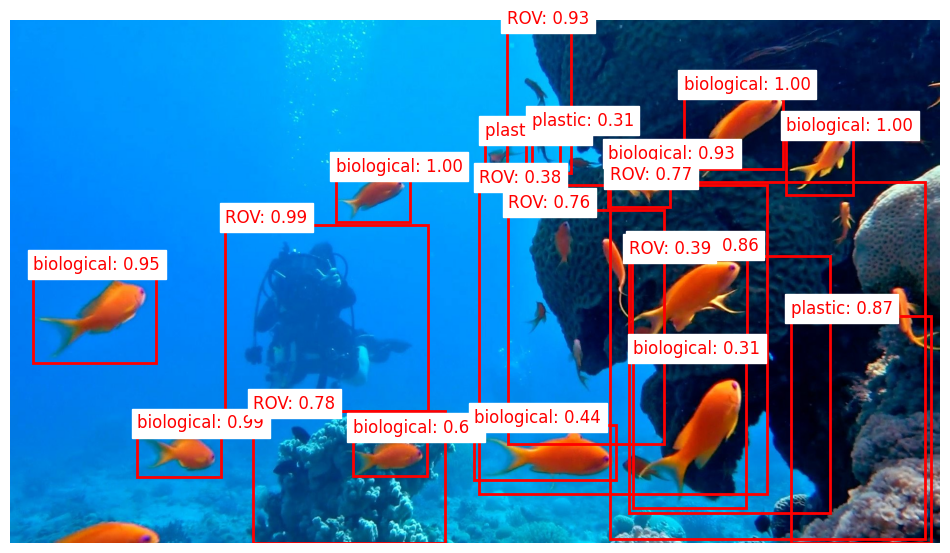

(array([[1602.4906  ,  232.89401 , 1739.533   ,  361.018   ],
        [ 672.373   ,  317.1016  ,  824.42786 ,  417.6562  ],
        [1390.293   ,  148.01216 , 1595.4299  ,  308.28827 ],
        [ 262.59656 ,  847.1331  ,  434.34763 ,  942.7689  ],
        [ 443.4378  ,  423.76514 ,  863.0167  ,  806.0635  ],
        [  47.596947,  520.621   ,  300.48636 ,  708.8765  ],
        [1025.2211  ,   12.138136, 1156.7098  ,  316.45514 ],
        [1234.5941  ,  290.53665 , 1361.3228  ,  384.92035 ],
        [1611.1989  ,  610.66174 , 1900.0751  , 1080.      ],
        [1283.0321  ,  481.29507 , 1520.1396  ,  697.8712  ],
        [ 501.62717 ,  806.0817  ,  898.4835  , 1080.      ],
        [1238.1495  ,  334.51038 , 1887.6974  , 1071.6038  ],
        [1028.2487  ,  391.2584  , 1349.4408  ,  875.7039  ],
        [ 979.5042  ,  243.43192 , 1065.6168  ,  321.87573 ],
        [ 706.8004  ,  856.00165 ,  861.393   ,  941.2666  ],
        [ 958.37396 ,  835.30615 , 1250.6151  ,  949.453   ],
        

In [31]:
image_path = "/kaggle/input/test-image/test3.jpg"
run_inference_on_image(model, image_path, device=DEVICE, score_thr=0.3)

In [32]:
def iou_xyxy(boxA, boxB):
    xa1, ya1, xa2, ya2 = boxA
    xb1, yb1, xb2, yb2 = boxB

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    areaA = max(0.0, (xa2 - xa1) * (ya2 - ya1))
    areaB = max(0.0, (xb2 - xb1) * (yb2 - yb1))

    union = areaA + areaB - inter_area

    iou = inter_area / union if union > 0 else 0.0
    return inter_area, union, iou

In [58]:
import numpy as np

def box_iou_numpy(boxesA, boxesB):
    boxesA = np.asarray(boxesA, dtype=np.float32)
    boxesB = np.asarray(boxesB, dtype=np.float32)

    # FIX: auto-expand single boxes
    if boxesA.ndim == 1:
        boxesA = boxesA[None, :]
    if boxesB.ndim == 1:
        boxesB = boxesB[None, :]

    N = boxesA.shape[0]
    M = boxesB.shape[0]

    ious = np.zeros((N, M), dtype=np.float32)

    for i in range(N):
        xa1, ya1, xa2, ya2 = boxesA[i]
        areaA = max(0.0, (xa2 - xa1) * (ya2 - ya1))

        for j in range(M):
            xb1, yb1, xb2, yb2 = boxesB[j]

            inter_x1 = max(xa1, xb1)
            inter_y1 = max(ya1, yb1)
            inter_x2 = min(xa2, xb2)
            inter_y2 = min(ya2, yb2)

            inter_w = max(0.0, inter_x2 - inter_x1)
            inter_h = max(0.0, inter_y2 - inter_y1)
            inter_area = inter_w * inter_h

            areaB = max(0.0, (xb2 - xb1) * (yb2 - yb1))

            union = areaA + areaB - inter_area

            ious[i, j] = inter_area / union if union > 0 else 0.0

    return ious


In [34]:
import torch

def box_iou_torch(boxes1, boxes2):
    N = boxes1.shape[0]
    M = boxes2.shape[0]

    boxes1 = boxes1[:, None, :] 
    boxes2 = boxes2[None, :, :] 

    inter_x1 = torch.max(boxes1[..., 0], boxes2[..., 0])
    inter_y1 = torch.max(boxes1[..., 1], boxes2[..., 1])
    inter_x2 = torch.min(boxes1[..., 2], boxes2[..., 2])
    inter_y2 = torch.min(boxes1[..., 3], boxes2[..., 3])

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h

    area1 = ((boxes1[..., 2] - boxes1[..., 0]) * (boxes1[..., 3] - boxes1[..., 1])).clamp(min=0)
    area2 = ((boxes2[..., 2] - boxes2[..., 0]) * (boxes2[..., 3] - boxes2[..., 1])).clamp(min=0)

    union = area1 + area2 - inter_area
    iou = torch.where(union > 0, inter_area / union, torch.zeros_like(inter_area))
    return iou  # shape (N, M)


In [35]:
def xywh_to_xyxy(box):
    xc, yc, w, h = box
    x1 = xc - w/2
    y1 = yc - h/2
    x2 = xc + w/2
    y2 = yc + h/2
    return [x1, y1, x2, y2]

def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    xc = x1 + w/2
    yc = y1 + h/2
    return [xc, yc, w, h]


In [36]:
def match_predictions_to_gts(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thresh=0.5):
    order = np.argsort(-pred_scores)
    preds = pred_boxes[order]
    plabels = pred_labels[order]

    gt_matched = [False] * len(gt_boxes)
    tp = []
    fp = []

    for pbox, plab in zip(preds, plabels):
        gt_indices = [i for i, gl in enumerate(gt_labels) if gl == plab]
        if len(gt_indices) == 0:
            tp.append(0)
            fp.append(1)
            continue

        ious = [iou_xyxy(pbox, gt_boxes[i])[2] for i in gt_indices]
        best_idx = np.argmax(ious)
        best_iou = ious[best_idx]
        best_gt_idx = gt_indices[best_idx]

        if best_iou >= iou_thresh and not gt_matched[best_gt_idx]:
            tp.append(1)
            fp.append(0)
            gt_matched[best_gt_idx] = True
        else:
            tp.append(0)
            fp.append(1)
    return tp, fp

In [37]:
import csv
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import pandas as pd
TEST_DIR = os.path.join(DATA_ROOT, "test")
TEST_IMG_DIR = os.path.join(TEST_DIR, "images")
TEST_LABEL_DIR = os.path.join(TEST_DIR, "labels")
SCORE_TH = 0.05   
IOU_MATCH_TH = 0.5    
VIS_KEEP_SCORE = 0.3 
OUT_CSV = os.path.join(OUTPUT_DIR, "iou_report.csv")
CLASS_NAMES = {1: "plastic", 2: "biological", 3: "ROV"}

In [38]:
def match_preds_to_gts_with_ious(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thresh=IOU_MATCH_TH):
    P = len(pred_boxes)
    G = len(gt_boxes)
    matches = []
    if P == 0 or G == 0:
        return matches, list(range(P)), list(range(G))

    iou_mat = box_iou_numpy(pred_boxes, gt_boxes)

    order = np.argsort(-pred_scores)
    gt_matched = [False] * G

    for pi in order:
        pl = int(pred_labels[pi])
        gt_indices_same_class = [gi for gi in range(G) if int(gt_labels[gi]) == pl and not gt_matched[gi]]
        if len(gt_indices_same_class) == 0:
            continue
        ious_for_pred = [(gi, float(iou_mat[pi, gi])) for gi in gt_indices_same_class]
        best_gi, best_iou = max(ious_for_pred, key=lambda x: x[1])
        if best_iou >= iou_thresh:
            matches.append((pi, best_gi, pl, best_iou))
            gt_matched[best_gi] = True

    matched_pred_indices = [m[0] for m in matches]
    matched_gt_indices   = [m[1] for m in matches]
    unmatched_pred_indices = [i for i in range(P) if i not in matched_pred_indices]
    unmatched_gt_indices   = [i for i in range(G) if i not in matched_gt_indices]

    return matches, unmatched_pred_indices, unmatched_gt_indices

In [39]:
class TestTrashDataset(TrashDataset):
    def __init__(self, root_dir, transforms=None):
        super().__init__(root_dir, transforms=transforms)
    def __getitem__(self, idx):
        img, tgt = self.load_raw(idx)
        target = {
            "boxes": tgt["boxes"],
            "labels": tgt["labels"],
            "image_id": torch.tensor([idx]),
            "area": (tgt["boxes"][:,2]-tgt["boxes"][:,0])*(tgt["boxes"][:,3]-tgt["boxes"][:,1]) if len(tgt["boxes"])>0 else torch.tensor([]),
            "iscrowd": torch.zeros((len(tgt["boxes"]),), dtype=torch.int64)
        }
        if self.transforms:
            img, target = self.transforms(img, target)
        else:
            img = F.to_tensor(img)
        return img, target

In [40]:
test_ds = TestTrashDataset(TEST_DIR, transforms=get_transform(train=False))
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

best_ckpt = os.path.join("", "/kaggle/input/underwater-object-detection-resnet50/pytorch/default/1/outputs_resnet_aug/best_resnet50.pth")
if os.path.exists(best_ckpt):
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    print("Loaded checkpoint:", best_ckpt)
else:
    print("Warning: checkpoint not found; using current model weights.")

model.to(DEVICE)
model.eval()

rows = []
all_matched_ious = []
per_class_ious = {} 
total_gt = 0
total_pred = 0
total_matches = 0
total_fp = 0

for img_idx, (imgs, tgts) in enumerate(tqdm(test_loader, desc="IoU Eval on test set")):
    img_tensor = imgs[0]        
    gt = tgts[0]
    gt_boxes = gt["boxes"].cpu().numpy() if "boxes" in gt and len(gt["boxes"])>0 else np.zeros((0,4))
    gt_labels = gt["labels"].cpu().numpy() if "labels" in gt and len(gt["labels"])>0 else np.zeros((0,), dtype=np.int64)

    with torch.no_grad():
        outputs = model([img_tensor.to(DEVICE)])
    pred = outputs[0] if len(outputs)>0 else None

    if pred is None:
        pred_boxes = np.zeros((0,4))
        pred_scores = np.zeros((0,))
        pred_labels = np.zeros((0,), dtype=np.int64)
    else:
        pred_boxes = pred["boxes"].cpu().numpy() if "boxes" in pred and len(pred["boxes"])>0 else np.zeros((0,4))
        pred_scores = pred["scores"].cpu().numpy() if "scores" in pred and len(pred["scores"])>0 else np.zeros((0,))
        pred_labels = pred["labels"].cpu().numpy() if "labels" in pred and len(pred["labels"])>0 else np.zeros((0,), dtype=np.int64)

    keep_mask = pred_scores >= SCORE_TH
    pred_boxes = pred_boxes[keep_mask]
    pred_scores = pred_scores[keep_mask]
    pred_labels = pred_labels[keep_mask]

    total_gt += len(gt_boxes)
    total_pred += len(pred_boxes)

    matches, unmatched_preds, unmatched_gts = match_preds_to_gts_with_ious(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_thresh=IOU_MATCH_TH)

    matched_ious = [m[3] for m in matches] 
    total_matches += len(matches)
    total_fp += len(unmatched_preds)

    for (pidx, gidx, cls, iouv) in matches:
        per_class_ious.setdefault(int(cls), []).append(iouv)
        all_matched_ious.append(iouv)

    mean_iou_matched = float(np.mean(matched_ious)) if len(matched_ious)>0 else 0.0
    row = {
        "image_index": int(img_idx),
        "num_gt": int(len(gt_boxes)),
        "num_pred": int(len(pred_boxes)),
        "num_matched": int(len(matches)),
        "num_unmatched_preds": int(len(unmatched_preds)),
        "num_unmatched_gts": int(len(unmatched_gts)),
        "mean_iou_matched": mean_iou_matched
    }
    rows.append(row)

mean_iou_all_matches = float(np.mean(all_matched_ious)) if len(all_matched_ious)>0 else 0.0
print("\nIoU Evaluation")
print(f"Total images evaluated: {len(test_ds)}")
print(f"Total GT boxes: {total_gt}")
print(f"Total Predictions (score>={SCORE_TH}): {total_pred}")
print(f"Total Matched (TP IoU>={IOU_MATCH_TH}): {total_matches}")
print(f"Total False Positives (unmatched preds): {total_fp}")
print(f"Total False Negatives (unmatched GTs): {total_gt - total_matches}")
print(f"Mean IoU over matched pairs: {mean_iou_all_matches:.4f}")

print("\nPer-class mean IoU for matched pairs:")
for cls_id in sorted(per_class_ious.keys()):
    arr = np.array(per_class_ious[cls_id])
    print(f"  Class {cls_id} ({CLASS_NAMES.get(cls_id,'cls'+str(cls_id))}): mean IoU = {arr.mean():.4f} over {len(arr)} matches")

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print("\nPer-image IoU report saved to:", OUT_CSV)

if len(all_matched_ious) > 0:
    sorted_ious = sorted(all_matched_ious)
    print("\nExample IoU stats (matched pairs):")
    print(f"  Min IoU: {sorted_ious[0]:.4f}")
    print(f"  10th percentile IoU: {np.percentile(sorted_ious, 10):.4f}")
    print(f"  Median IoU: {np.median(sorted_ious):.4f}")
    print(f"  90th percentile IoU: {np.percentile(sorted_ious, 90):.4f}")
    print(f"  Max IoU: {sorted_ious[-1]:.4f}")
else:
    print("No matched pairs found; check SCORE_TH or IOU_MATCH_TH settings.")

Loaded checkpoint: /kaggle/input/underwater-object-detection-resnet50/pytorch/default/1/outputs_resnet_aug/best_resnet50.pth


IoU Eval on test set:   0%|          | 0/1144 [00:00<?, ?it/s]


IoU Evaluation
Total images evaluated: 1144
Total GT boxes: 1668
Total Predictions (score>=0.05): 3134
Total Matched (TP IoU>=0.5): 1652
Total False Positives (unmatched preds): 1482
Total False Negatives (unmatched GTs): 16
Mean IoU over matched pairs: 0.8615

Per-class mean IoU for matched pairs:
  Class 1 (plastic): mean IoU = 0.8545 over 933 matches
  Class 2 (biological): mean IoU = 0.8686 over 392 matches
  Class 3 (ROV): mean IoU = 0.8733 over 327 matches

Per-image IoU report saved to: outputs_resnet_aug/iou_report.csv

Example IoU stats (matched pairs):
  Min IoU: 0.5109
  10th percentile IoU: 0.7546
  Median IoU: 0.8797
  90th percentile IoU: 0.9473
  Max IoU: 0.9928


In [41]:
import numpy as np
from collections import defaultdict

def iou_np(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0,xB-xA) * max(0,yB-yA)

    areaA = max(0, (boxA[2]-boxA[0])*(boxA[3]-boxA[1]))
    areaB = max(0, (boxB[2]-boxB[0])*(boxB[3]-boxB[1]))

    union = areaA + areaB - inter
    return inter/union if union>0 else 0

In [42]:
def compute_detection_stats(preds_by_image, gts_by_image, num_classes, iou_thr=0.5):
    stats = {c: {"TP":0, "FP":0, "FN":0} for c in range(1, num_classes+1)}

    for img_id in range(len(preds_by_image)):
        p = preds_by_image[img_id]
        g = gts_by_image[img_id]

        p_boxes = p["boxes"].numpy()
        p_scores = p["scores"].numpy()
        p_labels = p["labels"].numpy()

        g_boxes = g["boxes"].numpy()
        g_labels = g["labels"].numpy()

        matched_gt = set()

        for pi, (pb, pl) in enumerate(zip(p_boxes, p_labels)):
            best_iou = 0
            best_gi = -1
            for gi, (gb, gl) in enumerate(zip(g_boxes, g_labels)):
                if pl != gl: 
                    continue
                iou = iou_np(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi
            
            if best_iou >= iou_thr:
                stats[pl]["TP"] += 1
                matched_gt.add(best_gi)
            else:
                stats[pl]["FP"] += 1

        for cls in range(1, num_classes+1):
            stats[cls]["FN"] += np.sum(g_labels == cls) - \
                                sum(1 for gi in matched_gt if g_labels[gi] == cls)

    return stats

In [43]:
def compute_classification_metrics(stats):
    metrics = {}

    for cls, v in stats.items():
        TP = v["TP"]
        FP = v["FP"]
        FN = v["FN"]

        precision = TP / (TP + FP + 1e-9)
        recall    = TP / (TP + FN + 1e-9)
        f1        = 2*precision*recall / (precision+recall+1e-9)
        accuracy  = TP / (TP + FP + FN + 1e-9)

        metrics[cls] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy
        }
    return metrics

In [44]:
def evaluate_map_range(preds_by_image, gts_by_image, num_classes):
    aps_iou = []
    per_class_ap_iou = {c:[] for c in range(1, num_classes+1)}

    for iou_thr in np.arange(0.5, 1.0, 0.05):
        mean_ap, per_class = evaluate_map_from_preds(preds_by_image, gts_by_image, num_classes, iou_thr)
        aps_iou.append(mean_ap)
        for c, ap in per_class.items():
            if ap is not None:
                per_class_ap_iou[c].append(ap)

    class_map5095 = {c: float(np.mean(v)) if len(v)>0 else None
                     for c,v in per_class_ap_iou.items()}

    return float(np.mean(aps_iou)), class_map5095

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

def build_confusion_matrix(preds_by_image, gts_by_image, num_classes, iou_thr=0.5):
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)

    for img_id in range(len(preds_by_image)):
        p = preds_by_image[img_id]
        g = gts_by_image[img_id]

        p_boxes = p["boxes"].numpy()
        p_labels = p["labels"].numpy()
        g_boxes = g["boxes"].numpy()
        g_labels = g["labels"].numpy()

        used = set()

        for pi, pb in enumerate(p_boxes):
            pl = p_labels[pi]

            best_iou = 0
            best_gi = -1
            for gi, gb in enumerate(g_boxes):
                iou = iou_np(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi

            if best_iou >= iou_thr:
                gl = g_labels[best_gi]
                cm[gl-1][pl-1] += 1
                used.add(best_gi)
            else:
                pass

        for gi, gl in enumerate(g_labels):
            if gi not in used:
                cm[gl-1][gl-1] += 0  

    return cm

def plot_cm(cm, classes):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=classes, yticklabels=classes, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix")
    plt.show()

In [52]:
def compute_pr_curve(preds_by_image, gts_by_image, cls_id=None, combined=False, iou_thr=0.5):
    scores = []
    tps = []
    fps = []

    total_gt = 0

    for img_id in range(len(preds_by_image)):
        pred = preds_by_image[img_id]
        gt   = gts_by_image[img_id]

        p_boxes  = pred["boxes"].numpy()
        p_scores = pred["scores"].numpy()
        p_labels = pred["labels"].numpy()

        g_boxes  = gt["boxes"].numpy()
        g_labels = gt["labels"].numpy()

        # count relevant GT
        if combined:
            total_gt += len(g_boxes)
        else:
            total_gt += np.sum(g_labels == cls_id)

        gt_used = np.zeros(len(g_boxes))

        for pb, ps, pl in zip(p_boxes, p_scores, p_labels):

            # per-class filtering
            if not combined:
                if pl != cls_id:
                    continue

            scores.append(ps)

            best_iou = 0
            best_gi = -1

            for gi, (gb, gl) in enumerate(zip(g_boxes, g_labels)):

                if not combined and gl != cls_id:
                    continue

                iou = iou_np(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi

            if best_iou >= iou_thr and best_gi >= 0 and not gt_used[best_gi]:
                tps.append(1)
                fps.append(0)
                gt_used[best_gi] = 1
            else:
                tps.append(0)
                fps.append(1)

    if len(scores) == 0:
        return [0], [0], [0]

    scores = np.array(scores)
    order = np.argsort(-scores)

    tps = np.array(tps)[order]
    fps = np.array(fps)[order]

    tp_cum = np.cumsum(tps)
    fp_cum = np.cumsum(fps)

    recall = tp_cum / (total_gt + 1e-9)
    precision = tp_cum / (tp_cum + fp_cum + 1e-9)

    return precision, recall, scores[order]

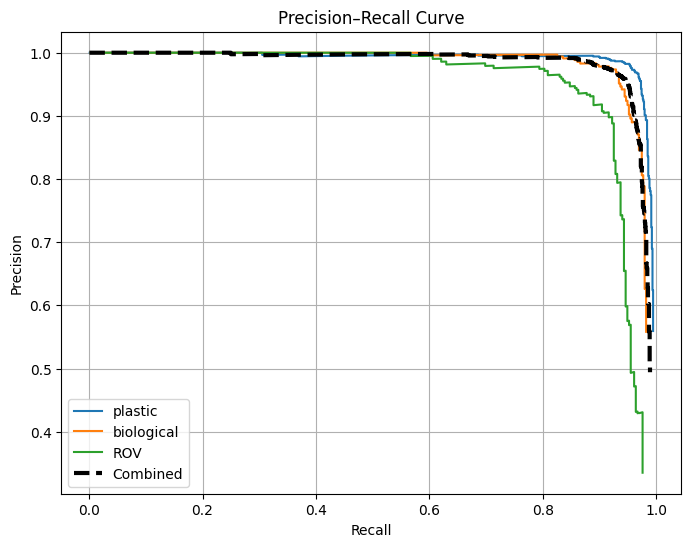

In [53]:
plt.figure(figsize=(8,6))

for cls_id, cls_name in CLASS_NAMES.items():
    prec, rec, conf = compute_pr_curve(preds_by_image, gts_by_image, cls_id=cls_id, combined=False)
    plt.plot(rec, prec, label=cls_name)

prec_c, rec_c, conf_c = compute_pr_curve(preds_by_image, gts_by_image, combined=True)
plt.plot(rec_c, prec_c, label="Combined", linewidth=3, linestyle="--", color="black")

plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

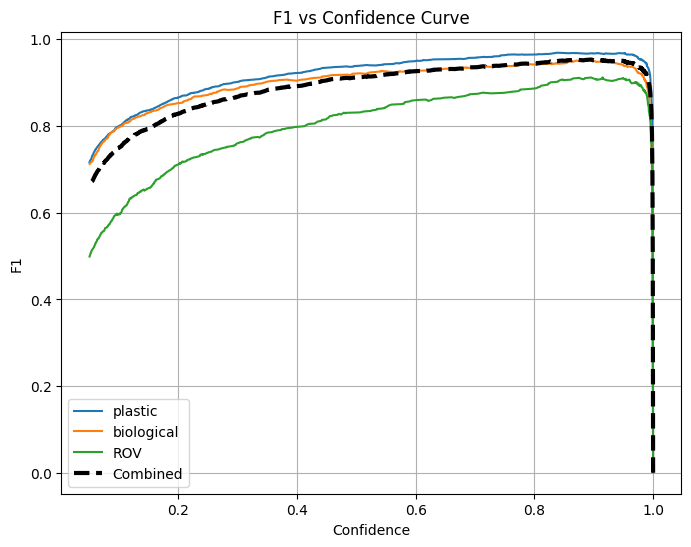

In [54]:
plt.figure(figsize=(8,6))

for cls_id, cls_name in CLASS_NAMES.items():
    prec, rec, conf = compute_pr_curve(preds_by_image, gts_by_image, cls_id=cls_id)
    f1 = 2*prec*rec / (prec+rec+1e-9)
    plt.plot(conf, f1, label=cls_name)

prec_c, rec_c, conf_c = compute_pr_curve(preds_by_image, gts_by_image, combined=True)
f1_c = 2*prec_c*rec_c / (prec_c+rec_c+1e-9)
plt.plot(conf_c, f1_c, label="Combined", linewidth=3, linestyle="--", color="black")

plt.title("F1 vs Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

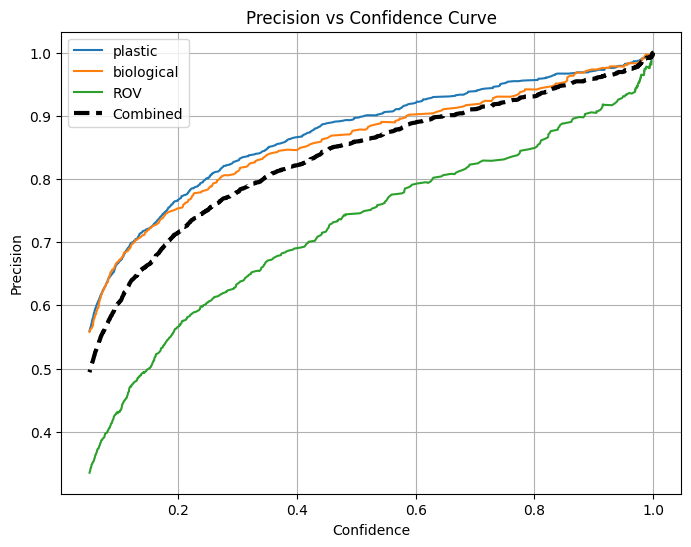

In [55]:
plt.figure(figsize=(8,6))
for cls_id, cls_name in CLASS_NAMES.items():
    prec, rec, conf = compute_pr_curve(preds_by_image, gts_by_image, cls_id=cls_id)
    plt.plot(conf, prec, label=cls_name)

prec_c, rec_c, conf_c = compute_pr_curve(preds_by_image, gts_by_image, combined=True)
plt.plot(conf_c, prec_c, label="Combined", linewidth=3, linestyle="--", color="black")

plt.title("Precision vs Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

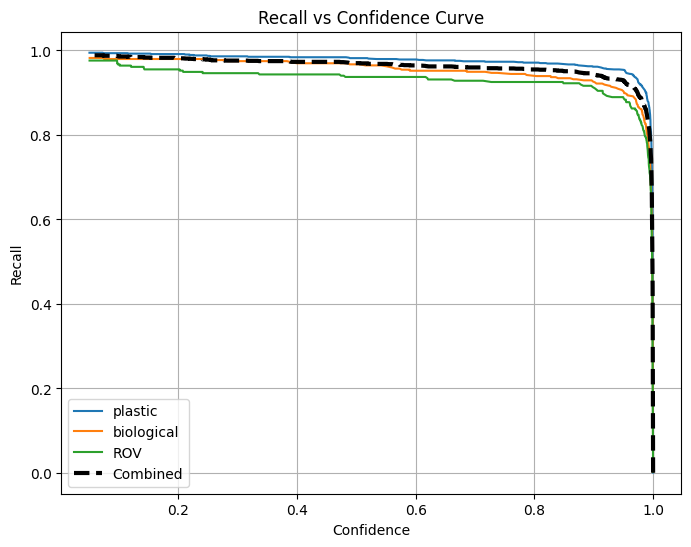

In [56]:
plt.figure(figsize=(8,6))
for cls_id, cls_name in CLASS_NAMES.items():
    prec, rec, conf = compute_pr_curve(preds_by_image, gts_by_image, cls_id=cls_id)
    plt.plot(conf, rec, label=cls_name)

prec_c, rec_c, conf_c = compute_pr_curve(preds_by_image, gts_by_image, combined=True)
plt.plot(conf_c, rec_c, label="Combined", linewidth=3, linestyle="--", color="black")

plt.title("Recall vs Confidence Curve")
plt.xlabel("Confidence")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
map50, per_class50 = evaluate_map_from_preds(preds_by_image, gts_by_image, NUM_CLASSES, iou_thresh=0.5)
map5095, map5095_per_class = evaluate_map_range(preds_by_image, gts_by_image, NUM_CLASSES)

print(f"mAP@50: {map50:.4f}")
print(f"mAP@50-95: {map5095:.4f}")
print("Per-class mAP50:", per_class50)
print("Per-class mAP50-95:", map5095_per_class)

mAP@50: 0.9688
mAP@50-95: 0.7166
Per-class mAP50: {1: 0.9878572378225741, 2: 0.9739764057993732, 3: 0.9446329444903423}
Per-class mAP50-95: {1: 0.6967971106313648, 2: 0.7227746415419214, 3: 0.7301972968304843}


In [60]:
df_results = pd.DataFrame({
    "Class": [CLASS_NAMES[c] for c in map5095_per_class.keys()],
    "Support": [np.sum([ (gts_by_image[i]["labels"].numpy()==c).sum()
                         for i in range(len(gts_by_image)) ])
                for c in map5095_per_class.keys()],
    "AP@50-95": [map5095_per_class[c] for c in map5095_per_class.keys()]
})
print(df_results)

        Class  Support  AP@50-95
0     plastic      937  0.696797
1  biological      396  0.722775
2         ROV      335  0.730197


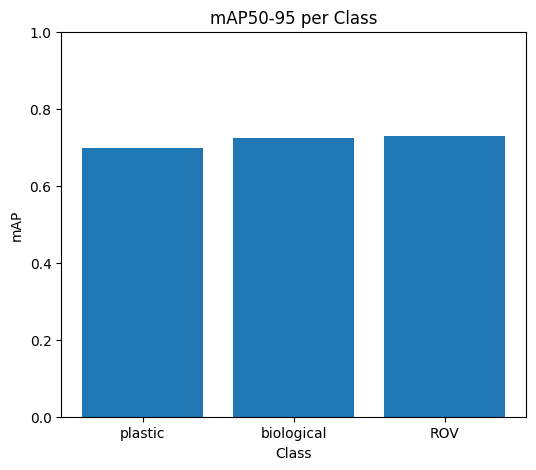

In [61]:
plt.figure(figsize=(6,5))
plt.bar(df_results["Class"], df_results["AP@50-95"])
plt.title("mAP50-95 per Class")
plt.ylabel("mAP")
plt.xlabel("Class")
plt.ylim(0,1)
plt.show()

In [62]:
stats = compute_detection_stats(preds_by_image, gts_by_image, NUM_CLASSES)
metrics = compute_classification_metrics(stats)

In [63]:
print("\nCLASSIFICATION METRICS")
rows = []
for cls_id, name in CLASS_NAMES.items():
    m = metrics[cls_id]
    support = sum((gts_by_image[i]["labels"].numpy() == cls_id).sum()
                  for i in range(len(gts_by_image)))

    rows.append({
        "Class": name,
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1-score": m["f1"],
        "Accuracy": m["accuracy"],
        "Support": support
    })
df_scores = pd.DataFrame(rows)
print(df_scores)


CLASSIFICATION METRICS
        Class  Precision    Recall  F1-score  Accuracy  Support
0     plastic   0.590636  0.994944  0.741243  0.588869      937
1  biological   0.592539  0.983333  0.739481  0.586648      396
2         ROV   0.372951  0.978495  0.540059  0.369919      335


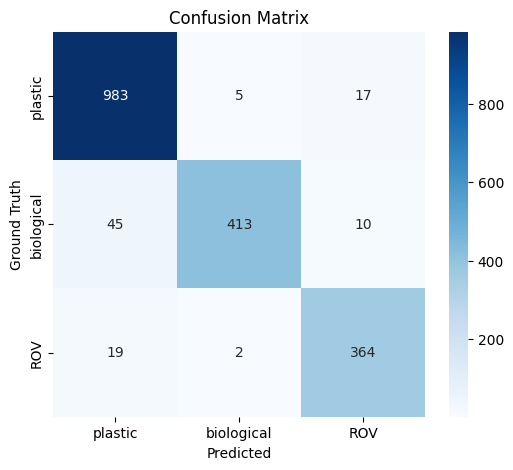

In [67]:
cm = build_confusion_matrix(preds_by_image, gts_by_image, NUM_CLASSES)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES.values(),
            yticklabels=CLASS_NAMES.values(),
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.show()